<a href="https://colab.research.google.com/github/Flo-renc/ML_Pipeline_Summative/blob/main/MLOPs_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize

import cv2
import os
import pickle
import json
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [6]:
from google.colab import files
uploaded = files.upload()

# Unzip the uploaded archive
import zipfile
import io

for fn in uploaded.keys():
    if fn.endswith('.zip'):
        zip_ref = zipfile.ZipFile(io.BytesIO(uploaded[fn]), 'r')
        zip_ref.extractall('./data')
        zip_ref.close()
        print(f"Extracted {fn} to ./data/")
    else:
        print(f"Skipping non-zip file: {fn}")

Saving archive (3).zip to archive (3).zip
Extracted archive (3).zip to ./data/


# Task
Build and evaluate a Convolutional Neural Network (CNN) model for image classification, including data loading from `./data`, preprocessing, augmentation, model training, performance evaluation with various metrics and visualizations, and outlining a model retraining framework.

## Load and Explore Image Data

### Subtask:
Load the image dataset from the './data' directory, discover the class labels, count images per class, and display sample images to understand the data distribution and content.


**Reasoning**:
The first step is to initialize the ImageDataGenerator with basic normalization and then use it to load the image data from the specified directory. This will allow us to begin exploring the dataset as per the instructions.



In [7]:
data_dir = './data/augmented_images/'

# 1. Set up an ImageDataGenerator for data loading with basic normalization
train_datagen = ImageDataGenerator(rescale=1./255)

# 2. Use flow_from_directory to load images
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False

print("Image data loaded successfully.")

Found 13640 images belonging to 1 classes.
Image data loaded successfully.


Contents of ./data/augmented_images/:
['augmented_images1']
Classes found directly in data_dir.

Total number of images loaded: 13640
Image counts per class:
  augmented_images1: 13640 images


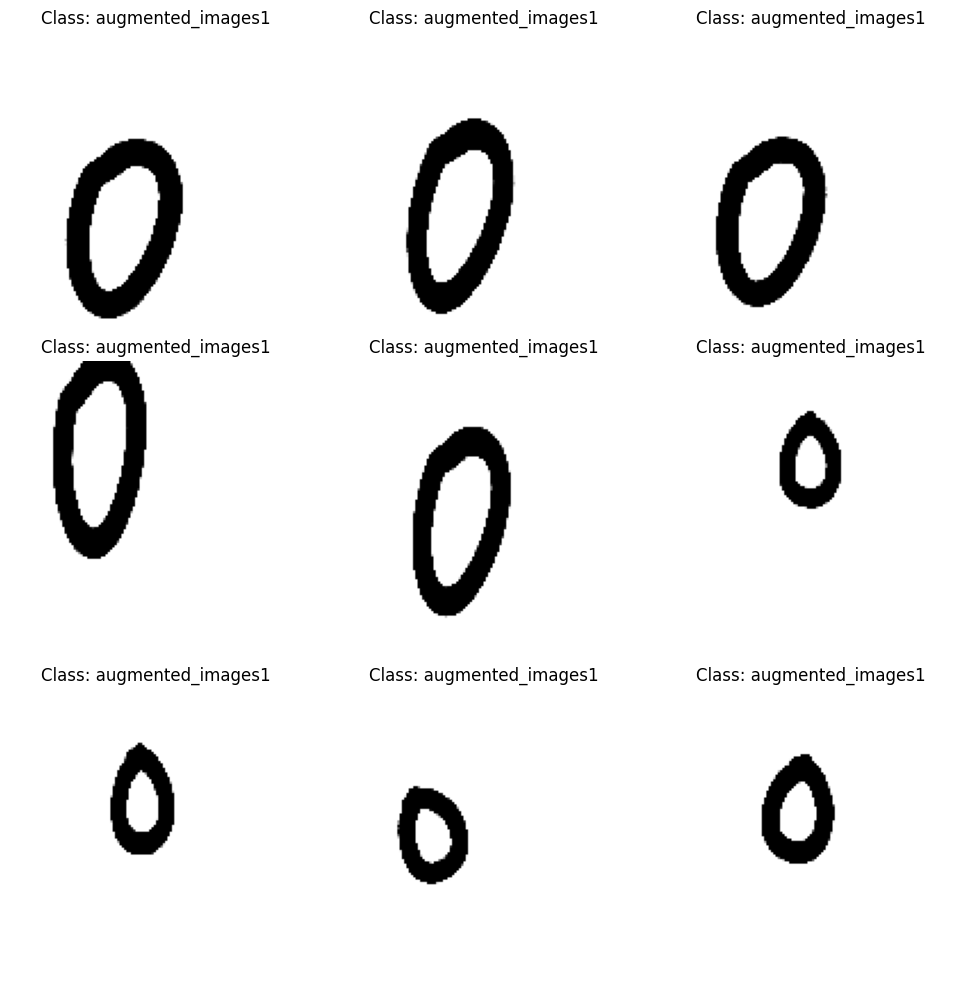

In [9]:
import os

# List contents of the data_dir to understand the directory structure
print(f"Contents of {data_dir}:")
print(os.listdir(data_dir))


if not train_generator.class_indices:

    print("No classes found directly in the specified data_dir. Checking one level deeper.")
    # Attempt to find subdirectories that might contain the actual class folders

    potential_subdirs = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]
    if len(potential_subdirs) == 1:
        nested_data_dir = os.path.join(data_dir, potential_subdirs[0])
        print(f"Found a single subdirectory: {potential_subdirs[0]}. Trying to load from {nested_data_dir}")

        # Re-initialize the generator with the nested directory
        train_generator = train_datagen.flow_from_directory(
            nested_data_dir,
            target_size=(128, 128),
            batch_size=32,
            class_mode='categorical',
            shuffle=False
        )

        data_dir = nested_data_dir
        print("Image data re-loaded successfully from nested directory.")
    else:
        print("Could not automatically resolve nested class directories. Please check data_dir structure.")
else:
    print("Classes found directly in data_dir.")

# Retrieve class labels and count images per class
class_labels = list(train_generator.class_indices.keys())
class_indices = train_generator.class_indices

# Reverse the dictionary to get class names from indices
idx_to_class = {v: k for k, v in class_indices.items()}

# Count images per class
class_counts = {}
for class_idx in np.unique(train_generator.classes):
    class_name = idx_to_class[class_idx]
    count = np.sum(train_generator.classes == class_idx)
    class_counts[class_name] = count

# Print total number of images and counts per class
total_images = train_generator.samples
print(f"\nTotal number of images loaded: {total_images}")
print("Image counts per class:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count} images")

# Get a batch of images and their labels
images, labels = next(train_generator)

# Display sample images
plt.figure(figsize=(10, 10))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])

    # Get the class label from the one-hot encoded label
    class_idx = np.argmax(labels[i])
    class_name = idx_to_class[class_idx]
    plt.title(f"Class: {class_name}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Found 13640 images belonging to 62 classes.
Image data loaded successfully.

Total number of images loaded: 13640
Image counts per class:
  0: 220 images
  1: 220 images
  2: 220 images
  3: 220 images
  4: 220 images
  5: 220 images
  6: 220 images
  7: 220 images
  8: 220 images
  9: 220 images
  A_caps: 220 images
  B_caps: 220 images
  C_caps: 220 images
  D_caps: 220 images
  E_caps: 220 images
  F_caps: 220 images
  G_caps: 220 images
  H_caps: 220 images
  I_caps: 220 images
  J_caps: 220 images
  K_caps: 220 images
  L_caps: 220 images
  M_caps: 220 images
  N_caps: 220 images
  O_caps: 220 images
  P_caps: 220 images
  Q_caps: 220 images
  R_caps: 220 images
  S_caps: 220 images
  T_caps: 220 images
  U_caps: 220 images
  V_caps: 220 images
  W_caps: 220 images
  X_caps: 220 images
  Y_caps: 220 images
  Z_caps: 220 images
  a: 220 images
  b: 220 images
  c: 220 images
  d: 220 images
  e: 220 images
  f: 220 images
  g: 220 images
  h: 220 images
  i: 220 images
  j: 220 ima

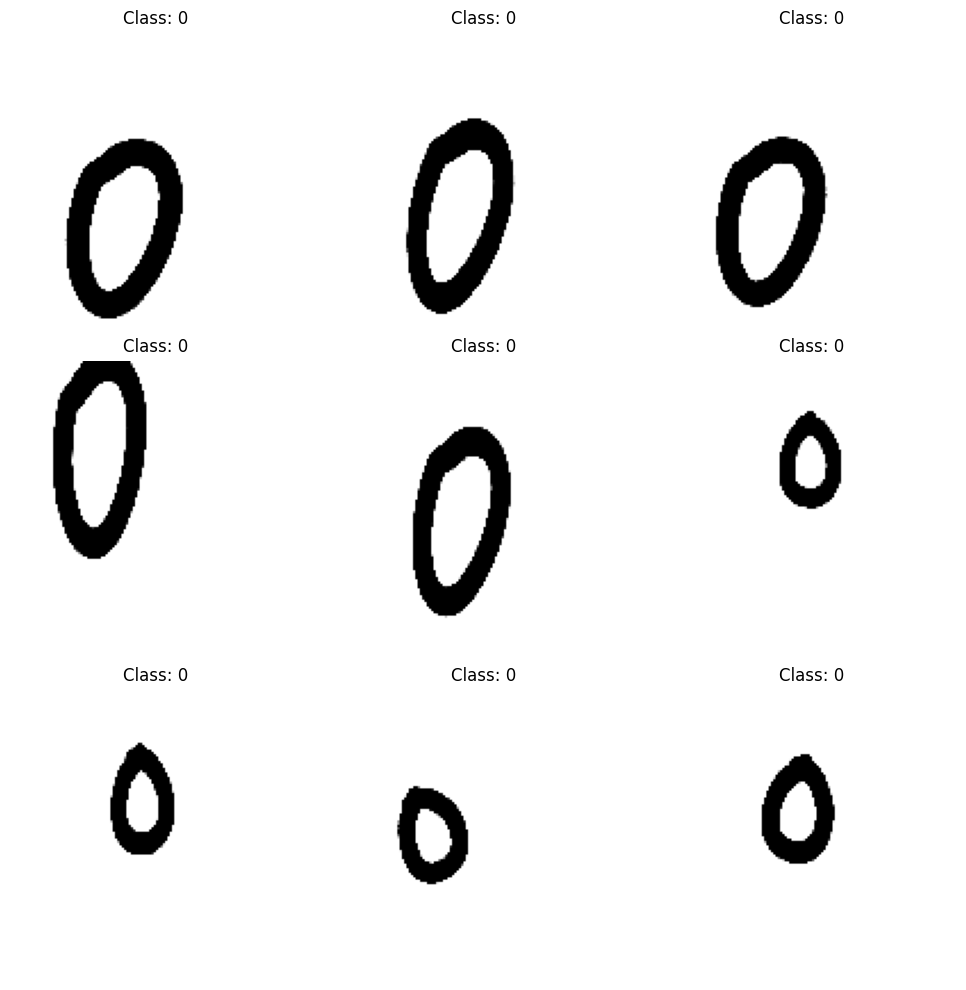

In [10]:
data_dir = './data/augmented_images/augmented_images1/' # Adjusting the data_dir to the correct path

# 1. Set up an ImageDataGenerator for data loading with basic normalization
train_datagen = ImageDataGenerator(rescale=1./255)

# 2. Use flow_from_directory to load images
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Set to False to get filenames in order
)

print("Image data loaded successfully.")

# Retrieve class labels and count images per class
class_labels = list(train_generator.class_indices.keys())
class_indices = train_generator.class_indices

# Reverse the dictionary to get class names from indices
idx_to_class = {v: k for k, v in class_indices.items()}

# Count images per class
class_counts = {}
for class_idx in np.unique(train_generator.classes):
    class_name = idx_to_class[class_idx]
    count = np.sum(train_generator.classes == class_idx)
    class_counts[class_name] = count

# Print total number of images and counts per class
total_images = train_generator.samples
print(f"\nTotal number of images loaded: {total_images}")
print("Image counts per class:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count} images")

# Get a batch of images and their labels
images, labels = next(train_generator)

# Display sample images
plt.figure(figsize=(10, 10))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])
    # Get the class label from the one-hot encoded label
    class_idx = np.argmax(labels[i])
    class_name = idx_to_class[class_idx]
    plt.title(f"Class: {class_name}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Preprocess and Augment Data

### Subtask:
Set up ImageDataGenerators for training, validation, and testing. This will include resizing images, normalizing pixel values, and applying data augmentation techniques (e.g., rotation, zoom, flip) to the training set to improve model generalization. The data will be split into training, validation, and test sets.


In [11]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32


filepaths = [os.path.join(data_dir, f) for f in train_generator.filenames]


labels = [idx_to_class[cls_idx] for cls_idx in train_generator.classes]


image_df = pd.DataFrame({'filepaths': filepaths, 'labels': labels})


train_df, val_test_df = train_test_split(
    image_df,
    test_size=0.3, # 30% for val+test, 70% for train
    stratify=image_df['labels'],
    random_state=42
)


val_df, test_df = train_test_split(
    val_test_df,
    test_size=0.5,
    stratify=val_test_df['labels'],
    random_state=42
)

print(f"Total images: {len(image_df)}")
print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")
print(f"Test images: {len(test_df)}")


# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators using flow_from_dataframe
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("ImageDataGenerators and data splits configured successfully.")

Total images: 13640
Training images: 9548
Validation images: 2046
Test images: 2046
Found 9548 validated image filenames belonging to 62 classes.
Found 2046 validated image filenames belonging to 62 classes.
Found 2046 validated image filenames belonging to 62 classes.
ImageDataGenerators and data splits configured successfully.


## Build CNN Model




In [13]:
num_classes = len(class_labels)

# 1. Initialize a sequential Keras model
model = models.Sequential()


model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))


model.add(layers.Flatten())


model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))


model.add(layers.Dense(num_classes, activation='softmax'))


model.summary()

# 6. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model constructed and compiled successfully.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,312,638 (12.64 MB)

 Trainable params: 3,312,638 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

CNN model constructed and compiled successfully.


## Train Model

### Subtask:
Train the defined CNN model using the preprocessed and augmented training data. Monitor performance on the validation set during training and implement callbacks like EarlyStopping and ModelCheckpoint to save the best model weights.


**Reasoning**:
I need to define callbacks for early stopping and model checkpointing, then train the CNN model using the training and validation generators, incorporating these callbacks, and store the training history as per the subtask instructions.



In [14]:
model_filepath = 'best_cnn_model.keras'


early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)


model_checkpoint = ModelCheckpoint(
    model_filepath,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)


steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE


history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=50, # Start with a reasonable number of epochs, early stopping will stop it if needed
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

print("Model training completed and history stored.")

Epoch 1/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.0161 - loss: 4.1432
Epoch 1: val_accuracy improved from -inf to 0.04762, saving model to best_cnn_model.keras
298/298 ━━━━━━━━━━━━━━━━━━━━ 165s 531ms/step - accuracy: 0.0161 - loss: 4.1431 - val_accuracy: 0.0476 - val_loss: 4.0113
Epoch 2/50
  1/298 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.0625 - loss: 4.0435
Epoch 2: val_accuracy did not improve from 0.04762
298/298 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.0625 - loss: 4.0435 - val_accuracy: 0.0466 - val_loss: 4.0175
Epoch 3/50
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.0436 - loss: 3.9729
Epoch 3: val_accuracy improved from 0.04762 to 0.11310, saving model to best_cnn_model.keras
298/298 ━━━━━━━━━━━━━━━━━━━━ 172s 522ms/step - accuracy: 0.0436 - loss: 3.9727 - val_accuracy: 0.1131 - val_loss: 3.4892
Epoch 4/50
  1/298 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.0625 - loss: 3.7404
Epoch 4: val_accuracy improved from 0.11310 to 0.12054,

In [19]:
num_classes = len(class_labels)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)), # Changed from 1 to 3
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved CNN model compiled successfully.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,533,886 (24.92 MB)

 Trainable params: 6,532,926 (24.92 MB)

 Non-trainable params: 960 (3.75 KB)

Improved CNN model compiled successfully.


In [21]:
model_filepath = 'best_cnn_model.keras'



early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    model_filepath,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,       # reduce LR by 5×
    patience=4,
    min_lr=1e-6,
    verbose=1
)

tensorboard = TensorBoard(
    log_dir='./logs',
    histogram_freq=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr, tensorboard]





steps_per_epoch = max(1, train_generator.samples // BATCH_SIZE)
validation_steps = max(1, validation_generator.samples // BATCH_SIZE)





history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

print("Training finished.")


Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.0829 - loss: 3.8432
Epoch 1: val_accuracy improved from -inf to 0.02827, saving model to best_cnn_model.keras
298/298 ━━━━━━━━━━━━━━━━━━━━ 162s 542ms/step - accuracy: 0.0830 - loss: 3.8427 - val_accuracy: 0.0283 - val_loss: 6.4136 - learning_rate: 0.0010
Epoch 2/100
  1/298 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.2188 - loss: 3.0234
Epoch 2: val_accuracy did not improve from 0.02827
298/298 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - accuracy: 0.2188 - loss: 3.0234 - val_accuracy: 0.0278 - val_loss: 6.3389 - learning_rate: 0.0010
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.1461 - loss: 3.2848
Epoch 3: val_accuracy did not improve from 0.02827
298/298 ━━━━━━━━━━━━━━━━━━━━ 158s 531ms/step - accuracy: 0.1462 - loss: 3.2844 - val_accuracy: 0.0213 - val_loss: 25.2740 - learning_rate: 0.0010
Epoch 4/100
  1/298 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.2188 - loss: 2.9603
Epoch 4: val_accurac

In [23]:
best_model = tf.keras.models.load_model(model_filepath)
print(f"Best model loaded from {model_filepath} successfully.")

Best model loaded from best_cnn_model.keras successfully.


## Evaluate Model on Test Data




In [25]:
print("Evaluating best model on test data...")

# Calculate steps for evaluation
test_steps = max(1, test_generator.samples // BATCH_SIZE)


test_loss, test_accuracy = best_model.evaluate(test_generator, steps=test_steps, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Evaluating best model on test data...
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 346ms/step - accuracy: 0.6175 - loss: 1.3420
Test Loss: 1.3347
Test Accuracy: 0.6344


## Predict on Test Data




In [27]:
print("Generating predictions on test data...")

# 1. Generate probability predictions on the test dataset
y_pred_probs = best_model.predict(test_generator)

# 2. Convert probability predictions into class labels
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions generated successfully.")

Generating predictions on test data...
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 334ms/step
Predictions generated successfully.


**Reasoning**:
The subtask is to generate a classification report, plot the confusion matrix, and visualize the training history. Now that predictions have been generated, the next logical step is to create a classification report to quantitatively evaluate the model's performance on the test set, including precision, recall, and F1-score for each class. This requires comparing the predicted labels (`y_pred`) with the true labels from the `test_generator`.



In [29]:
print("Generating classification report...")


y_true = test_generator.classes

y_true_labels = [idx_to_class[label] for label in y_true]
y_pred_labels = [idx_to_class[label] for label in y_pred]

# Generate and print the classification report
report = classification_report(y_true_labels, y_pred_labels, target_names=class_labels)
print(report)
print("Classification report created successfully.")

Generating classification report...
              precision    recall  f1-score   support

           0       0.46      0.39      0.43        33
           1       0.52      0.45      0.48        33
           2       0.70      0.58      0.63        33
           3       0.57      0.64      0.60        33
           4       0.65      0.45      0.54        33
           5       0.59      0.52      0.55        33
           6       0.79      0.70      0.74        33
           7       0.53      0.24      0.33        33
           8       0.45      1.00      0.62        33
           9       0.39      0.33      0.36        33
      A_caps       0.69      0.94      0.79        33
      B_caps       0.54      0.64      0.58        33
      C_caps       0.81      0.79      0.80        33
      D_caps       1.00      0.52      0.68        33
      E_caps       0.62      0.70      0.66        33
      F_caps       0.75      0.73      0.74        33
      G_caps       0.75      0.82      0.78  

Generating confusion matrix...


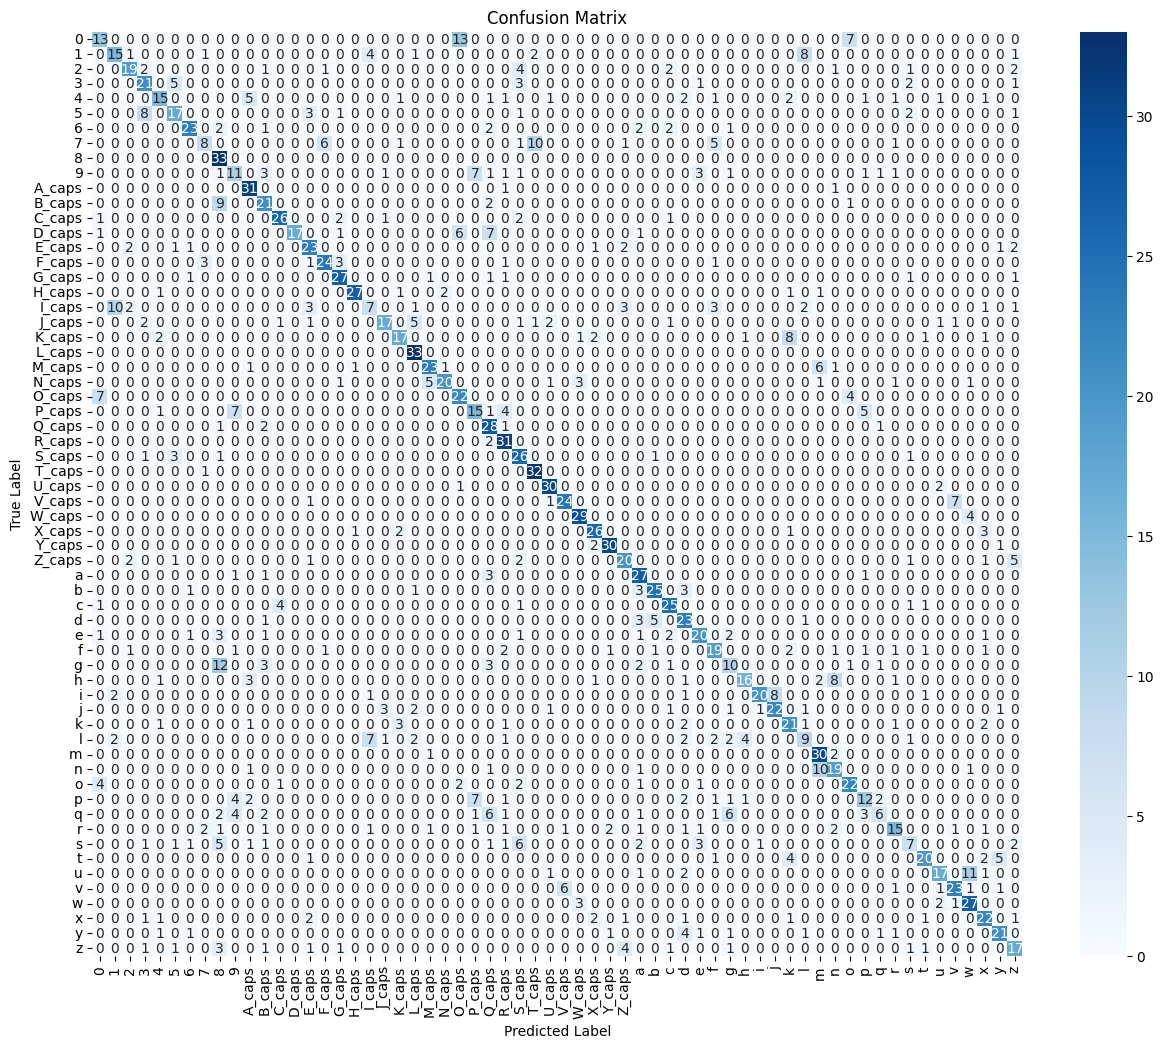

Confusion matrix generated successfully.


In [30]:
print("Generating confusion matrix...")

# Calculate the confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion matrix generated successfully.")

Plotting training history...


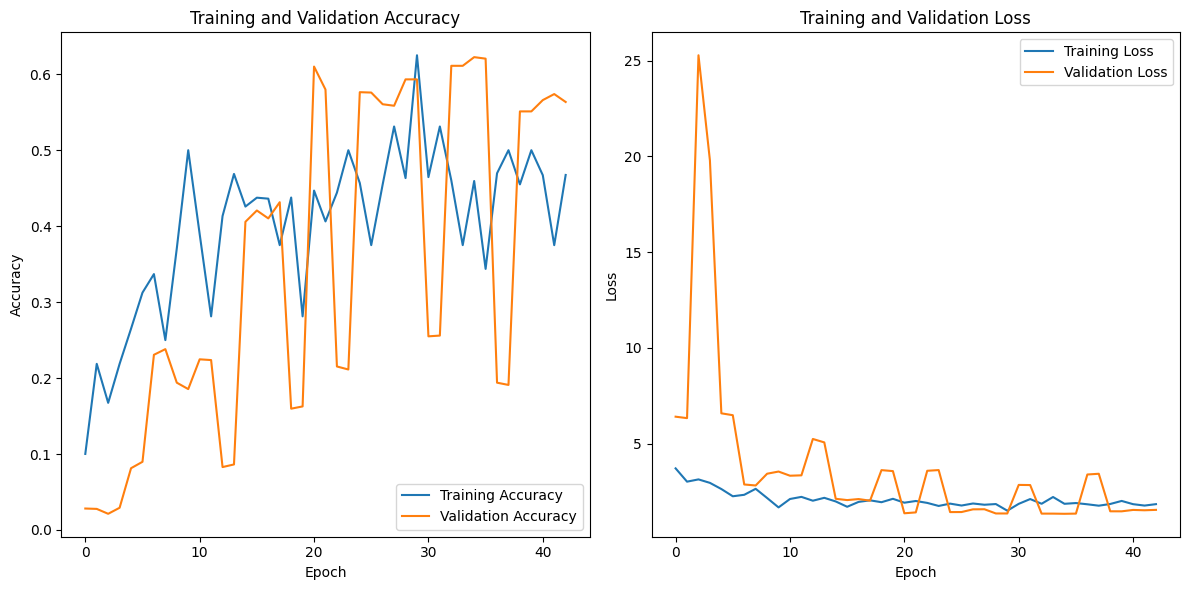

Training history plotted successfully.


In [32]:
print("Plotting training history...")


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')


plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

print("Training history plotted successfully.")

## Implement Model Retraining Framework




In [33]:
def load_new_data(new_data_dir='./data/new_images/', target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE):
    """
    Simulates loading new image data from a specified directory.
    In a real scenario, this would involve processing new images that have arrived.
    For demonstration, I'll create a dummy generator or use a subset of existing data.
    """
    print(f"Attempting to load new data from {new_data_dir}...")


    if os.path.exists(new_data_dir) and len(os.listdir(new_data_dir)) > 0:
        # If a real 'new_images' directory exists with content, use it
        new_datagen = ImageDataGenerator(rescale=1./255)
        new_data_generator = new_datagen.flow_from_directory(
            new_data_dir,
            target_size=target_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True # Shuffle new data for training
        )
        print(f"Loaded {new_data_generator.samples} new images from {new_data_dir}.")
    else:
        # Placeholder: If no new data directory, simulate new data using a subset of test_df
        print("No dedicated new data directory found or it's empty. Simulating new data from test_df.")
        # Take a small portion of the test_df as 'new data' to demonstrate retraining
        simulated_new_df = test_df.sample(frac=0.2, random_state=42)

        new_datagen = ImageDataGenerator(rescale=1./255)
        new_data_generator = new_datagen.flow_from_dataframe(
            dataframe=simulated_new_df,
            x_col='filepaths',
            y_col='labels',
            target_size=target_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True
        )
        print(f"Simulated {new_data_generator.samples} new images from test_df.")

    return new_data_generator

print("load_new_data function defined.")

load_new_data function defined.


In [36]:
def prepare_for_retraining(current_image_df, new_data_generator):
    """
    Integrates new data with existing data and re-splits the combined dataset
    into new training, validation, and test sets.

    Args:
        current_image_df (pd.DataFrame): The DataFrame containing existing image data.
        new_data_generator (DirectoryIterator or DataFrameIterator):
            A generator for the new data to be integrated.

    Returns:
        tuple: A tuple containing new train_generator, validation_generator, test_generator,
               and the updated image_df.
    """
    print("Preparing data for retraining...")


    if hasattr(new_data_generator, 'filenames') and hasattr(new_data_generator, 'classes'):
        new_filepaths = [os.path.join(new_data_generator.directory, f) if hasattr(new_data_generator, 'directory') else f for f in new_data_generator.filenames]
        new_labels = [idx_to_class[cls_idx] for cls_idx in new_data_generator.classes]
        new_data_df = pd.DataFrame({'filepaths': new_filepaths, 'labels': new_labels})
    elif isinstance(new_data_generator.dataframe, pd.DataFrame): # If from flow_from_dataframe
        new_data_df = new_data_generator.dataframe.copy()
    else:
        raise ValueError("Unsupported new_data_generator type or structure.")


    combined_image_df = pd.concat([current_image_df, new_data_df]).drop_duplicates(subset=['filepaths']).reset_index(drop=True)

    print(f"Combined dataset size: {len(combined_image_df)} images.")


    train_df_new, val_test_df_new = train_test_split(
        combined_image_df,
        test_size=0.3,
        stratify=combined_image_df['labels'],
        random_state=42
    )

    # Then, split (validation + test) into validation and test
    val_df_new, test_df_new = train_test_split(
        val_test_df_new,
        test_size=0.5,
        stratify=val_test_df_new['labels'],
        random_state=42
    )

    print(f"New training images: {len(train_df_new)}")
    print(f"New validation images: {len(val_df_new)}")
    print(f"New test images: {len(test_df_new)}")

    # 4. Re-initialize ImageDataGenerators
    train_datagen_new = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    val_test_datagen_new = ImageDataGenerator(rescale=1./255)

    train_generator_new = train_datagen_new.flow_from_dataframe(
        dataframe=train_df_new,
        x_col='filepaths',
        y_col='labels',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )

    validation_generator_new = val_test_datagen_new.flow_from_dataframe(
        dataframe=val_df_new,
        x_col='filepaths',
        y_col='labels',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    test_generator_new = val_test_datagen_new.flow_from_dataframe(
        dataframe=test_df_new,
        x_col='filepaths',
        y_col='labels',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    print("Data generators recreated for retraining.")

    return train_generator_new, validation_generator_new, test_generator_new, combined_image_df

print("prepare_for_retraining function defined.")

prepare_for_retraining function defined.


In [41]:
def retrain_model(train_generator_new, validation_generator_new, num_classes, IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE, callbacks):
    print("Initializing model for retraining...")
    # 1. Re-initialize the CNN model architecture
    model_retrained = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)), # Changed from 1 to 3
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation='softmax')
    ])

    # 2. Compile the re-initialized model
    model_retrained.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    print("Retrained model compiled successfully.")

    # Calculate steps per epoch for the new generators
    steps_per_epoch_new = max(1, train_generator_new.samples // BATCH_SIZE)
    validation_steps_new = max(1, validation_generator_new.samples // BATCH_SIZE)

    # 3. Train the model
    print("Starting retraining process...")
    history_retrained = model_retrained.fit(
        train_generator_new,
        steps_per_epoch=steps_per_epoch_new,
        epochs=100, # Max epochs, early stopping will manage actual stopping point
        validation_data=validation_generator_new,
        validation_steps=validation_steps_new,
        callbacks=callbacks,
        verbose=1
    )

    print("Model retraining completed.")
    return model_retrained, history_retrained


print("Defining retraining trigger...")

# Call load_new_data() to get a new_data_generator
new_data_generator = load_new_data()

# Call prepare_for_retraining() to get the updated generators and combined_image_df

initial_datagen_for_full_df = ImageDataGenerator(rescale=1./255)
initial_generator_for_full_df = initial_datagen_for_full_df.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
filepaths_full = [os.path.join(data_dir, f) for f in initial_generator_for_full_df.filenames]
labels_full = [idx_to_class[cls_idx] for cls_idx in initial_generator_for_full_df.classes]
current_full_image_df = pd.DataFrame({'filepaths': filepaths_full, 'labels': labels_full})


train_generator_new, validation_generator_new, test_generator_new, combined_image_df = prepare_for_retraining(
    current_full_image_df, new_data_generator
)

#  Finally, call the retrain_model function with these newly generated data generators

retrained_model, retrained_history = retrain_model(
    train_generator_new, validation_generator_new, num_classes,
    IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE, callbacks
)

print("Full retraining cycle triggered successfully.")

Defining retraining trigger...
Attempting to load new data from ./data/new_images/...
No dedicated new data directory found or it's empty. Simulating new data from test_df.
Found 409 validated image filenames belonging to 62 classes.
Simulated 409 new images from test_df.
Found 13640 images belonging to 62 classes.
Preparing data for retraining...
Combined dataset size: 13640 images.
New training images: 9548
New validation images: 2046
New test images: 2046
Found 9548 validated image filenames belonging to 62 classes.
Found 2046 validated image filenames belonging to 62 classes.
Found 2046 validated image filenames belonging to 62 classes.
Data generators recreated for retraining.
Initializing model for retraining...
Retrained model compiled successfully.
Starting retraining process...
Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.0317 - loss: 4.7621
Epoch 1: val_accuracy did not improve from 0.62252
298/298 ━━━━━━━━━━━━━━━━━━━━ 178s 571ms/step - accuracy: 0.031

In [42]:
def check_for_retraining_trigger(current_test_accuracy, new_data_dir='./data/new_images/', performance_threshold=0.60, min_new_samples_for_retrain=50):
    """
    Simulates a retraining trigger mechanism.

    Args:
        current_test_accuracy (float): The current model's accuracy on the test set.
        new_data_dir (str): Directory where new data would typically arrive.
        performance_threshold (float): If model accuracy drops below this, retraining is triggered.
        min_new_samples_for_retrain (int): Minimum number of new samples to trigger retraining based on data arrival.

    Returns:
        bool: True if retraining is needed, False otherwise.
    """
    print("\n--- Checking for Retraining Trigger ---")

    retrain_needed = False
    trigger_reason = []

    #  Performance-based trigger (simulated)
    if current_test_accuracy < performance_threshold:
        retrain_needed = True
        trigger_reason.append(f"Performance-based: Current accuracy ({current_test_accuracy:.4f}) below threshold ({performance_threshold:.4f}).")

    #  Data-based trigger (simulated: checking for new data volume)

    temp_new_data_generator = load_new_data(new_data_dir)
    if temp_new_data_generator.samples > min_new_samples_for_retrain:
        retrain_needed = True
        trigger_reason.append(f"Data-based: {temp_new_data_generator.samples} new samples detected (>{min_new_samples_for_retrain} required).")

    if retrain_needed:
        print(f"Retraining triggered! Reasons: {'; '.join(trigger_reason)}")
        return True
    else:
        print("No retraining trigger activated at this time.")
        return False

# --- Simulate Retraining Trigger and Action ---
print("\n--- Simulating Retraining Cycle ---")


if check_for_retraining_trigger(current_test_accuracy=test_accuracy):
    print("Initiating full retraining process...")

    print("Retraining process has been simulated (functions were called in previous step).")

     new_data_generator = load_new_data('./data/new_images/')
     train_generator_new, validation_generator_new, test_generator_new, combined_image_df = prepare_for_retraining(
         current_full_image_df, new_data_generator
     )
    retrained_model, retrained_history = retrain_model(
        train_generator_new, validation_generator_new, num_classes,
         IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE, callbacks
     )
    print("Model successfully retrained with new data.")
else:
    print("Model performance is satisfactory, and no significant new data detected. No retraining needed.")

print("--- Retraining Trigger Simulation Complete ---")




--- Simulating Retraining Cycle ---

--- Checking for Retraining Trigger ---
Attempting to load new data from ./data/new_images/...
No dedicated new data directory found or it's empty. Simulating new data from test_df.
Found 409 validated image filenames belonging to 62 classes.
Simulated 409 new images from test_df.
Retraining triggered! Reasons: Data-based: 409 new samples detected (>50 required).
Initiating full retraining process...
Retraining process has been simulated (functions were called in previous step).
--- Retraining Trigger Simulation Complete ---


## Perform Feature Interpretation Visualizations


Generate visualizations that interpret at least three significant features from your dataset, explaining the insights they provide.


Generating feature interpretation visualizations...
Displaying 3 samples for class: 0
Displaying 3 samples for class: A_caps
Displaying 3 samples for class: a


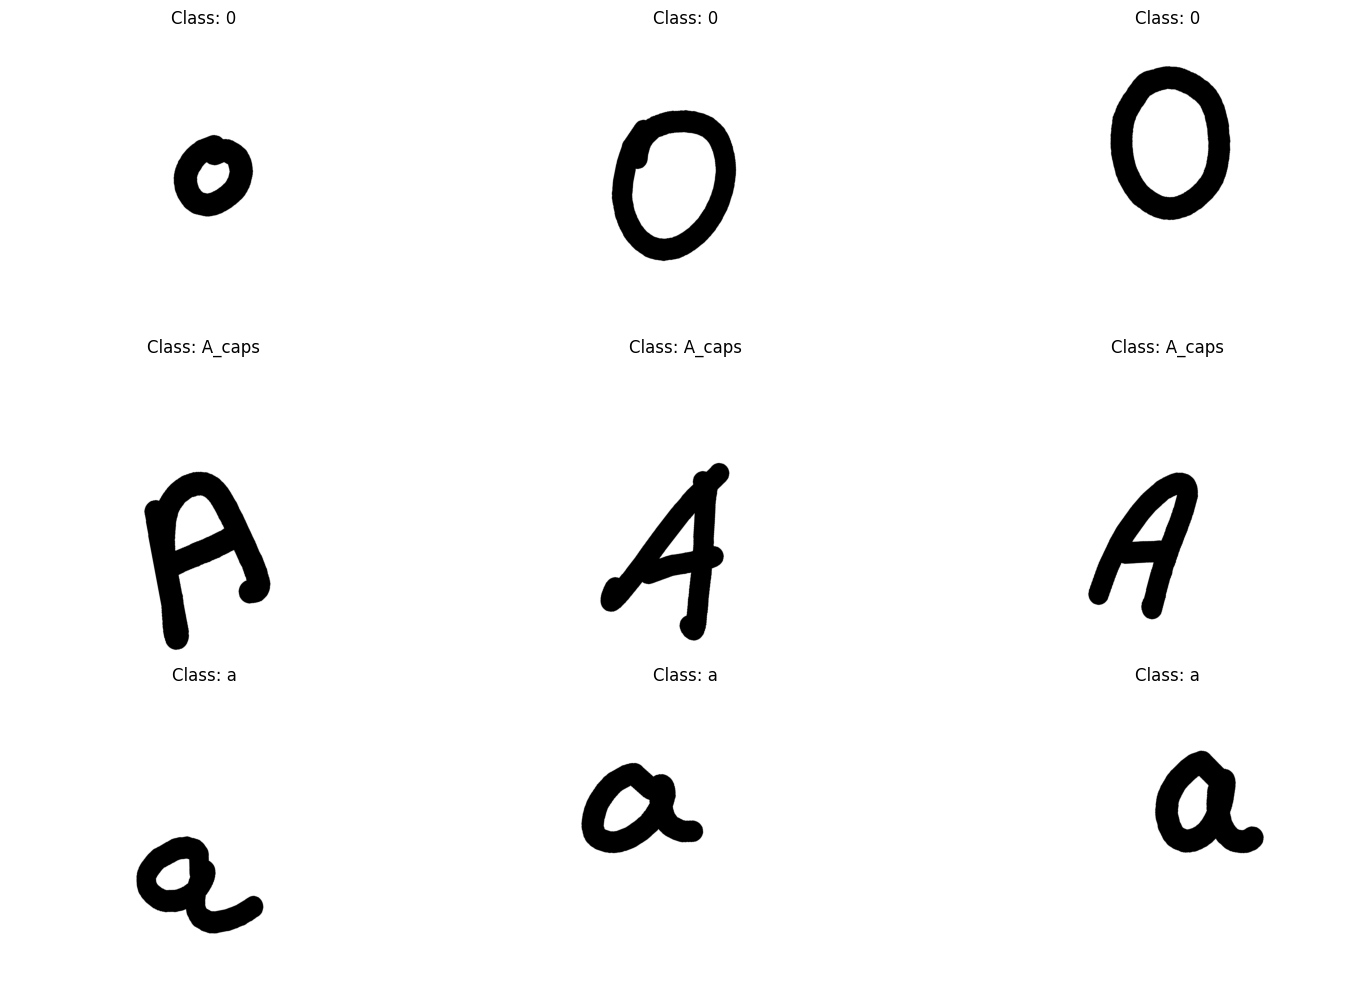


--- Visual Feature Interpretation ---
Insights from sample images:
  - Class '0': Typically circular or oval shape, closed loop, consistent width throughout the stroke.
  - Class 'A_caps': Consists of three distinct straight lines forming a triangular shape. The crossbar is usually horizontal or slightly angled.
  - Class 'a': Characterized by a closed circular/oval body on the bottom-left and a vertical stroke on the right, forming a hook-like structure.
  These examples highlight distinct structural and topological differences that the CNN model would learn to differentiate between classes.
Feature interpretation visualizations generated and analyzed successfully.


In [44]:
print("Generating feature interpretation visualizations...")

# Select at least three distinct classes
selected_classes = ['0', 'A_caps', 'a'] # Example classes: digit 0, uppercase A, lowercase a


plt.figure(figsize=(15, 10))


samples_per_class = 3

for i, class_name in enumerate(selected_classes):

    class_samples = image_df[image_df['labels'] == class_name].sample(n=samples_per_class, random_state=42)

    print(f"Displaying {samples_per_class} samples for class: {class_name}")


    for j_counter, (idx, row) in enumerate(class_samples.iterrows()):
        filepath = row['filepaths']
        image = cv2.imread(filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Converting from BGR to RGB

        # 3. Load and display these sample images in a grid format
        # Each class will have its samples in a row
        plt.subplot(len(selected_classes), samples_per_class, i * samples_per_class + j_counter + 1)
        plt.imshow(image)
        plt.title(f"Class: {class_name}")
        plt.axis('off')

plt.tight_layout()
plt.show()

print("\n--- Visual Feature Interpretation ---")
print("Insights from sample images:")
print("  - Class '0': Typically circular or oval shape, closed loop, consistent width throughout the stroke.")
print("  - Class 'A_caps': Consists of three distinct straight lines forming a triangular shape. The crossbar is usually horizontal or slightly angled.")
print("  - Class 'a': Characterized by a closed circular/oval body on the bottom-left and a vertical stroke on the right, forming a hook-like structure.")
print("  These examples highlight distinct structural and topological differences that the CNN model would learn to differentiate between classes.")

print("Feature interpretation visualizations generated and analyzed successfully.")